In [1]:
%pip install -q zoomy-core

# Shallow Water Tutorial with Numpy 
## Acknowledgements

The reference solution is based on 

```
 @article{Delestre_2013, 
 title={SWASHES: a compilation of Shallow Water Analytic Solutions for Hydraulic and Environmental Studies}, 
 volume={72}, 
 ISSN={0271-2091, 1097-0363}, DOI={10.1002/fld.3741}, 
 note={arXiv:1110.0288 [physics]}, 
 number={3}, 
 journal={International Journal for Numerical Methods in Fluids}, 
 author={Delestre, Olivier and Lucas, Carine and Ksinant, Pierre-Antoine and Darboux, Frédéric and Laguerre, Christian and Vo, Thi Ngoc Tuoi and James, Francois and Cordier, Stephane}, 
 year={2013}, 
 month=may, 
 pages={269–300} 
}
```

## Imports

In [35]:
import os
import numpy as np
from sympy import Matrix
import pytest
from attr import field, define
import matplotlib.pyplot as plt

from zoomy_core.fvm.solver_numpy import HyperbolicSolver, Settings
import zoomy_core.fvm.timestepping as timestepping
import zoomy_core.fvm.nonconservative_flux as nc_flux
from zoomy_core.model.basemodel import Model
import zoomy_core.model.initial_conditions as IC
import zoomy_core.model.boundary_conditions as BC
import zoomy_core.misc.io as io
from zoomy_core.mesh.lsq_reconstruction import compute_derivatives
from zoomy_core.misc.misc import Zstruct, ZArray
from zoomy_core.mesh import BaseMesh
import zoomy_core.postprocessing.postprocessing as postprocessing
import zoomy_core.mesh.browse_meshes as bm


## Model Definition

In [16]:
@define(frozen=True, slots=True, kw_only=True)
class SWE(Model):
    dimension: int = 1
    variables: Zstruct = field(init=False, default=dimension + 1)
    aux_variables: Zstruct = field(default=1)
    _default_parameters: dict = field(
        init=False,
        factory=lambda: {"g": 9.81, "ex": 0.0, "ey": 0.0, "ez": 1.0}
        )


    def project_2d_to_3d(self):
        out = ZArray.zeros(6)
        dim = self.dimension
        z = self.position[2]
        b = 0
        h = self.variables[0]
        U = [hu / h for hu in self.variables[1:1+dim]]
        rho_w = 1000.
        g = 9.81
        out[0] = b
        out[1] = h
        out[2] = U[0]
        out[3] = 0 if dim == 1 else U[1]
        out[4] = 0
        out[5] = rho_w * g * h * (1-z)
        return out

    def flux(self):
        dim = self.dimension
        h = self.variables[0]
        U = Matrix([hu / h for hu in self.variables[1:1+dim]])
        g = self.parameters.g
        I = Matrix.eye(dim)
        F = Matrix.zeros(self.variables.length(), dim)
        F[0, :] = (h * U)
        F[1:, :] = h * U * U.T + g/2 * h**2 * I
        
        return F

## Mesh Setup

In [17]:
await bm.show_meshes()

Meshes available:
 - channel_quad_2d_mesh
 - channel_quad_2d_mesh3d
 - square_mesh
 - square_mesh3d
 - square_mesh_triangular


['channel_quad_2d_mesh',
 'channel_quad_2d_mesh3d',
 'square_mesh',
 'square_mesh3d',
 'square_mesh_triangular']

In [18]:
await bm.download_mesh('square_mesh', filetype='h5')

Download complete.


'./square_mesh.h5'

In [19]:
mesh2d = petscMesh.Mesh.from_hdf5(
    "square_mesh.h5"
)


In [20]:
mesh2d.boundary_conditions_sorted_names

array(['wall', 'inflow', 'outflow'], dtype='<U7')

In [21]:
mesh1d = petscMesh.Mesh.create_1d(domain=(0.0, 10.0), n_inner_cells=200)


# 1D

## Boundary conditions and Model instantiation

In [25]:
bcs = BC.BoundaryConditions(
    [
        BC.Extrapolation(tag="left"),
        BC.Extrapolation(tag="right"),
    ]
)

def custom_ic(x):
    Q = np.zeros(2, dtype=float)
    Q[0] = np.where(x[0] < 5., 0.005, 0.001)
    return Q

ic = IC.UserFunction(custom_ic)

model1d = SWE(
    dimension=1,
    boundary_conditions=bcs,
    initial_conditions=ic,
)

## Solver Setup

In [26]:
class SWESolver(HyperbolicSolver):
    def update_qaux(self, Q, Qaux, Qold, Qauxold, mesh, model, parameters, time, dt):
        dudx = compute_derivatives(Q[1]/Q[0], mesh, derivatives_multi_index=[[0, 0]])[:,0]
        Qaux[0]=dudx
        return Qaux
    
settings = Settings(name="ShallowWater", output=Zstruct(directory="outputs/shallow_water_1d", filename="swe", clean_directory=True, snapshots=10))

## Solving

In [29]:
solver = SWESolver(time_end=6.0, settings=settings, compute_dt=timestepping.adaptive(CFL=0.95))
Qnew, Qaux = solver.solve(mesh1d, model1d)

2025-11-22 11:39:07.615 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 10, time: 1.795650, dt: 0.169894, next write at time: 2.000000
2025-11-22 11:39:07.721 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 20, time: 3.482447, dt: 0.168158, next write at time: 3.333333
2025-11-22 11:39:07.799 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 30, time: 5.160706, dt: 0.167634, next write at time: 5.333333
2025-11-22 11:39:07.898 | INFO     | zoomy_core.fvm.solver_numpy:solve:295 - Finished simulation with in 0.527 seconds


## VTK Postprocessing

In [30]:
io.generate_vtk(os.path.join(settings.output.directory, f"{settings.output.filename}.h5"))
postprocessing.vtk_project_2d_to_3d(model1d, settings, filename='out_3d')

2025-11-22 11:39:18.056 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 0/10
2025-11-22 11:39:18.205 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 1/10
2025-11-22 11:39:18.379 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 2/10
2025-11-22 11:39:18.543 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 3/10
2025-11-22 11:39:18.751 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 4/10
2025-11-22 11:39:18.936 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 5/10
2025-11-22 11:39:19.163 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 6/10
2025-11-22 11:39:19.365 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - 

In [31]:
# fig = plots_paper.plot_swe(os.path.join(settings.output.directory, settings.output.filename + ".h5"))

In [41]:
path = os.path.join(settings.output.directory, f"{settings.output.filename}.h5")
mesh = io.load_mesh_from_hdf5(path)
timeseries_data = io.load_fields_from_hdf5(path)

In [58]:
X = mesh.cell_centers[0]
Y = timeseries_data[0][0]

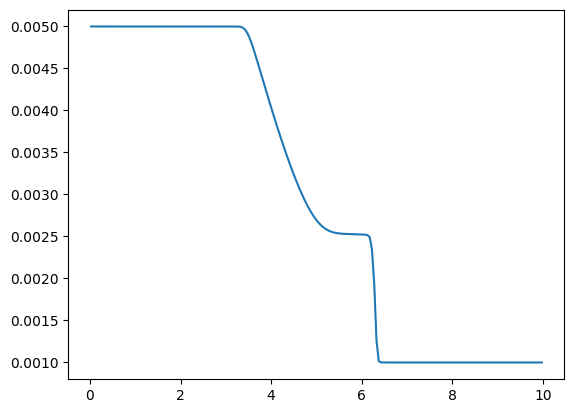

In [59]:
fig, ax = plt.subplots()
ax.plot(X[:mesh.n_inner_cells], Y[:mesh.n_inner_cells])

# 2D

## Boundary conditions and Model instantiation

In [60]:
mesh2d.boundary_conditions_sorted_names

array(['wall', 'inflow', 'outflow'], dtype='<U7')

In [69]:
bcs = BC.BoundaryConditions(
    [
        BC.Wall(tag="wall", momentum_field_indices=[[1, 2]]),
        BC.Extrapolation(tag="inflow"),
        BC.Extrapolation(tag="outflow"),

    ]
)

def custom_ic(x):
    Q = np.zeros(3, dtype=float)
    Q[0] = np.where(x[0] < 5., 0.005, 0.001)
    return Q

ic = IC.UserFunction(custom_ic)

@define(frozen=True, slots=True, kw_only=True)
class SWE2d(SWE):
    dimension: int = 2
    variables: Zstruct = field(init=False, default=dimension + 1)
    
# model1d = SWE2d(
#     boundary_conditions=bcs,
#     initial_conditions=ic,
# )

## Solver Setup

In [26]:
settings = Settings(name="ShallowWater", output=Zstruct(directory="outputs/shallow_water_2d", filename="swe", clean_directory=True, snapshots=10))

## Solving

In [29]:
solver = SWESolver(time_end=6.0, settings=settings, compute_dt=timestepping.adaptive(CFL=0.95))
Qnew, Qaux = solver.solve(mesh2d, model2d)

2025-11-22 11:39:07.615 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 10, time: 1.795650, dt: 0.169894, next write at time: 2.000000
2025-11-22 11:39:07.721 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 20, time: 3.482447, dt: 0.168158, next write at time: 3.333333
2025-11-22 11:39:07.799 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 30, time: 5.160706, dt: 0.167634, next write at time: 5.333333
2025-11-22 11:39:07.898 | INFO     | zoomy_core.fvm.solver_numpy:solve:295 - Finished simulation with in 0.527 seconds


## VTK Postprocessing

In [30]:
io.generate_vtk(os.path.join(settings.output.directory, f"{settings.output.filename}.h5"))
postprocessing.vtk_project_2d_to_3d(model2d, settings, filename='out_3d')

2025-11-22 11:39:18.056 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 0/10
2025-11-22 11:39:18.205 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 1/10
2025-11-22 11:39:18.379 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 2/10
2025-11-22 11:39:18.543 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 3/10
2025-11-22 11:39:18.751 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 4/10
2025-11-22 11:39:18.936 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 5/10
2025-11-22 11:39:19.163 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - Converted snapshot 6/10
2025-11-22 11:39:19.365 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:71 - 

In [ ]:
@pytest.mark.nbworking
def test_working():
    assert True